In [2]:
from qpe import *

from time import time

from scipy.stats import unitary_group, gaussian_kde
from scipy import sparse

from time import sleep
from multiprocessing import Pool

import matplotlib
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap

matplotlib.rcParams['font.family']='serif'
matplotlib.rcParams['axes.unicode_minus']=False
matplotlib.rcParams.update({'font.size': 20})
matplotlib.rc('text', usetex=True)

In [3]:
def swap_matrix(n_qudits, q1, q2, dim=2):
    p1, p2 = sorted([q1, q2])
    SW = zeros([dim**n_qudits, dim**n_qudits])
    SW_ph = zeros([dim, dim])
    for i in range(dim):
        for j in range(dim):
            SW_ph[i, j] = 1
            SW_ij = array(SW_ph)
            SW_ph[i, j] = 0
            SW_ph[j, i] = 1
            SW_ji = array(SW_ph)
            SW_ph[j, i] = 0
            op = reduce(kron, [eye(dim**p1), SW_ij, eye(dim**(p2 - p1 - 1)), SW_ji, eye(dim**(n_qudits - p2 - 1))])
            SW += op    
    return SW

def swap_matrix_sparse(n_qudits, q1, q2, dim=2):
    p1, p2 = sorted([q1, q2])
    SW = sparse.csr_array(zeros([dim**n_qudits, dim**n_qudits]))
    SW_ph = zeros([dim, dim])
    for i in range(dim):
        for j in range(dim):
            SW_ph[i, j] = 1
            SW_ij = array(SW_ph)
            SW_ph[i, j] = 0
            SW_ph[j, i] = 1
            SW_ji = array(SW_ph)
            SW_ph[j, i] = 0
            op = reduce(sparse.kron, [sparse.eye(dim**p1), SW_ij, sparse.eye(dim**(p2 - p1 - 1)), SW_ji, sparse.eye(dim**(n_qudits - p2 - 1))])
            SW += op    
    return SW

In [58]:
def aux_info(dms, labels, pars, ansatz, n_copies=1):

    n_tot = int(log2(len(dms[0])))*n_copies
    n_labels = len(labels)

    H = zeros([2**n_tot, 2**n_tot], dtype=complex)
    for par, op in zip(pars, ansatz):
        H += par*op
    H_sq = H@H

    expecs = zeros(n_labels, dtype=float)
    disps = zeros(n_labels, dtype=float)
    for i in range(n_labels):
        print("i = %d" %i, end="\r")
        dm_c = reduce(kron, [dms[i]]*n_copies)
        expecs[i] = trace(H@dm_c).real
        disps[i] = trace(H_sq@dm_c).real
    disps = disps - expecs**2
    
    return expecs, disps, H

#### Training data and settings

In [59]:
n_inp = 2
n_train = 100
n_test = 1000
mixed = True
marks = "neg"
eps = 1e-3

dms_train, labels_train = gen_even_ent_data(n_train, n_inp=n_inp, mixed=mixed, marks=marks, eps=eps)
dms_test, labels_test = gen_even_ent_data(n_test, n_inp=n_inp, mixed=mixed, marks=marks, eps=eps)

In [60]:
if mixed == False and dms_train.shape == (n_train, 2**n_inp):
    dms_train_pure = []
    dms_test_pure = []
    for i in range(n_train):
        dms_train_pure.append(outer(dms_train[i], dms_train[i].conj().T))
    for i in range(n_test):
        dms_test_pure.append(outer(dms_test[i], dms_test[i].conj().T))
    dms_train = array(dms_train_pure)
    dms_test = array(dms_test_pure)

In [61]:
purities_test = [trace(dm@dm).real for dm in dms_test]

In [62]:
n_copies = 4
n_tot = n_inp*n_copies
w_ls = 1e0
w_var = 1e-4
method = "BFGS"
options = {"maxiter": int(1e4)}#, "maxfun": int(1e10)}#

In [63]:
path = r"/home/kardashin/Work/Measure-once_regression/Results/"
info = "T=%d-w_ls=%f-w_var=%f-marks=%s-mixed=%s" %(n_train, w_ls, w_var, marks, mixed)

#### Ansatzes

In [64]:
# """ All 4^n Pauli matrices"""
# # Complicated? Saves RAM!
# n_pars = 4**n_tot
# ansatz = zeros([4**n_tot, 2**n_tot, 2**n_tot], dtype=complex)
# pauli_string_generator = product([I, X, Y, Z], repeat=n_tot)
# for i in range(4**n_tot):
#     ansatz[i] = reduce(kron, next(pauli_string_generator))

In [65]:
# """ Pairs of swaps """
# n_pars = int(n_tot*(n_tot - 1)/2) + 1
# c = 0
# ansatz = zeros([n_pars, 2**n_tot, 2**n_tot], dtype=complex)
# for i in range(n_tot):
#     for j in range(i):
#         ansatz[c] = swap_matrix(n_tot, i, j)
#         c += 1
# ansatz[-1] = eye(2**n_tot)

In [66]:
""" Some swaps and their products for four copies. Found heuristically. """

dim = 2

ansatz = []

ansatz.append(sparse.eye(dim**n_tot))

# (i, i+2)
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 4, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 3, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 3, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 5, 7, dim=dim)) # 6


ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 4, 6, dim=dim) + (swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 4, 6, dim=dim)).conj().T)
ansatz.append(swap_matrix_sparse(n_tot, 1, 3, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim)@swap_matrix_sparse(n_tot, 5, 7, dim=dim) + (swap_matrix_sparse(n_tot, 1, 3, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim)@swap_matrix_sparse(n_tot, 5, 7, dim=dim)).conj().T)
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 4, 6, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim)@swap_matrix_sparse(n_tot, 5, 7, dim=dim) + (swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 4, 6, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim)@swap_matrix_sparse(n_tot, 5, 7, dim=dim)).conj().T)


# (i, i+4)
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 3, 7, dim=dim)) # 10

# (i, i+6)
ansatz.append(swap_matrix_sparse(n_tot, 0, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 7, dim=dim)) # 12

# # (i, i+2)*(i, i+2)
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim)) # 13
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim)) # 17
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 4, dim=dim)@swap_matrix_sparse(n_tot, 3, 5, dim=dim))

# # (i, i+4)*(i, i+4)
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 2, 6, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 2, 6, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim)) 
ansatz.append(swap_matrix_sparse(n_tot, 2, 6, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim))
ansatz.append(swap_matrix_sparse(n_tot, 1, 5, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim)) # 27

# (i, i+6)*(i, i+6)
ansatz.append(swap_matrix_sparse(n_tot, 0, 6, dim=dim)@swap_matrix_sparse(n_tot, 1, 7, dim=dim)) # this

# # (i, i+2)*(i, i+2)*(i, i+2)*(i, i+2)
ansatz.append(swap_matrix_sparse(n_tot, 0, 2, dim=dim)@swap_matrix_sparse(n_tot, 1, 3, dim=dim)@swap_matrix_sparse(n_tot, 4, 6, dim=dim)@swap_matrix_sparse(n_tot, 5, 7, dim=dim))

# # (i, i+4)*(i, i+4)*(i, i+4)*(i, i+4)
ansatz.append(swap_matrix_sparse(n_tot, 0, 4, dim=dim)@swap_matrix_sparse(n_tot, 1, 5, dim=dim)@swap_matrix_sparse(n_tot, 2, 6, dim=dim)@swap_matrix_sparse(n_tot, 3, 7, dim=dim))


n_pars = len(ansatz)
n_pars

34

In [67]:
# """ good ansatz for two copies """

# dim = 2
# ansatz = []
# ansatz.append(eye(dim**n_tot))
# ansatz.append(swap_matrix(n_tot, 0, 2, dim=dim))
# ansatz.append(swap_matrix(n_tot, 1, 3, dim=dim))
# ansatz.append(swap_matrix(n_tot, 0, 2, dim=dim)@swap_matrix(n_tot, 1, 3, dim=dim))
# n_pars = len(ansatz)

#### Compute $L$ and $S$

In [68]:
time_start = time()
L = zeros((n_train, n_pars))
S = zeros((n_train, n_pars, n_pars))
for i in range(n_train):
    print("Computing L and S: i=%d" %i, end="\r")
    dm_c = reduce(kron, [dms_train[i]]*n_copies)
    for j in range(n_pars):
        op_loc = dm_c@ansatz[j]
        L[i][j] = trace(op_loc).real
        for k in range(n_pars):
            S[i][j][k] = trace(op_loc@ansatz[k]).real
time_finish = time() - time_start
print("Computing L and S: finished in %.2f s" %time_finish, end="\r")

#### Predict labels

In [69]:
# ### a better label for the negativity (?) ###
# labels_train_c = 337/461*array(labels_train)**2 + 124/461*array(labels_train)
# labels_test_c = 337/461*array(labels_test)**2 + 124/461*array(labels_test)

labels_train_c = array(labels_train)**2
labels_test_c = array(labels_test)**2

# labels_train_c = array(labels_train)**2 - array(labels_train)**4/4
# labels_test_c = array(labels_test)**2 - array(labels_test)**4/4

# labels_train_c = sqrt(1 - (1 - array(labels_train)**2/2)**4)
# labels_test_c = sqrt(1 - (1 - array(labels_test)**2/2)**4)

In [70]:
k = w_var/w_ls

B = L.T@L
C = np.sum(S + np.transpose(S, axes=(0, 2, 1)), axis=0)
A = (1 - k)*B + k/2*C
b = L.T@labels_train_c

pars = pinv(A)@b

In [71]:
time_start = time()
expecs_train, disps_train, H = aux_info(dms_train, labels_train_c, pars, ansatz, n_copies=n_copies)
expecs_test, disps_test, H = aux_info(dms_test, labels_test_c, pars, ansatz, n_copies=n_copies)
time_finish = time() - time_start
print("Prediction finished in %d s" %time_finish)

Prediction finished in 1 s


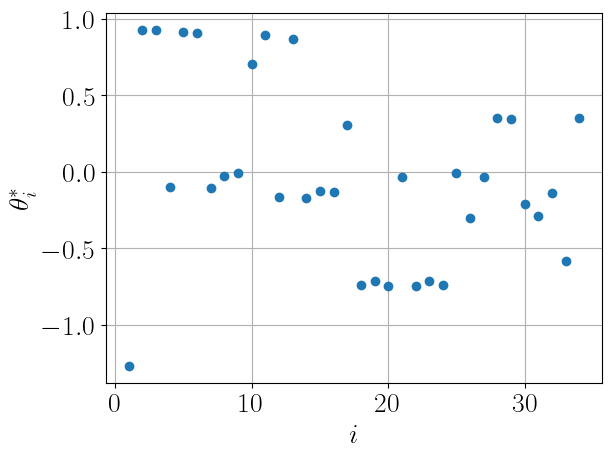

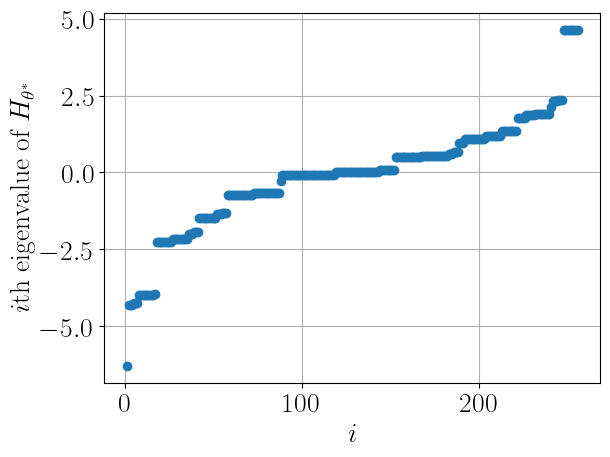

In [72]:
evals = eigh(H)[0]

plt.scatter(arange(1, len(pars) + 1), pars)
plt.xlabel(r"$i$")
plt.ylabel(r"$\theta_i^*$")
plt.grid()
plt.show()

plt.scatter(arange(1, 2**(n_inp*n_copies) + 1), evals)
plt.xlabel(r"$i$")
plt.ylabel(r"$i$th eigenvalue of $H_{\theta^*}$")
plt.grid()
plt.show()

n=2 | c=4 | k=0.000100 | 
marks: neg
n_pars: 34

MSE:            5.668835475880941e-05
Total variance: 0.8370967315369205


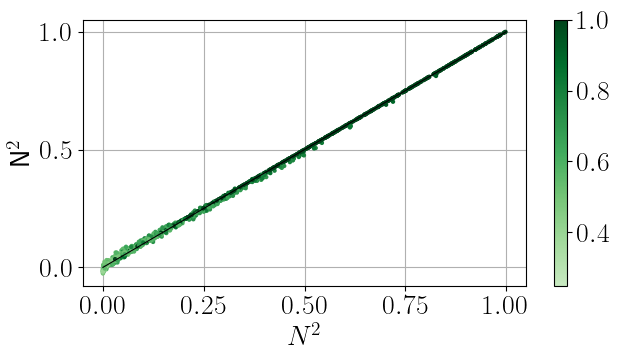

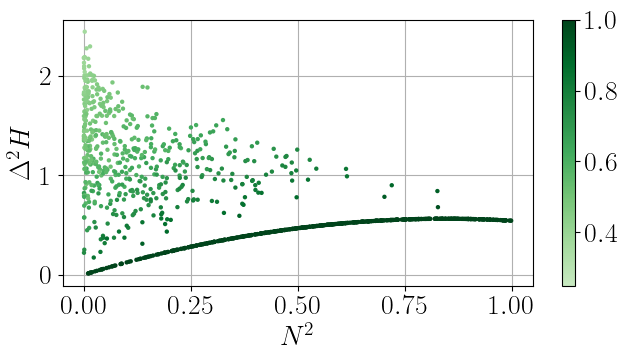

In [73]:
cmap_name = "Greens"
cmap = plt.get_cmap(cmap_name)
colors = cmap(np.linspace(0.25, 1., cmap.N))
cmap = LinearSegmentedColormap.from_list(cmap_name, colors)

print("n=%d | c=%d | k=%f | " %(n_inp, n_copies, k))
print("marks: %s" %marks)
print("n_pars: %d" %n_pars)
print()
print("MSE:           ", sum((expecs_test - labels_test_c)**2)/n_test)
print("Total variance:", sum(disps_test)/n_test)

plt.figure(figsize=(7, 4))
plt.rcParams['axes.axisbelow'] = True
plt.scatter(labels_test_c, expecs_test, c=purities_test, cmap=cmap, s=10, edgecolor='none', zorder=2) # , color="dodgerblue"
plt.plot(linspace(0, 1), linspace(0, 1), linestyle="-", linewidth=0.8, color="black")
# plt.plot(linspace(0, 3/4), linspace(0, 3/4), linestyle="-", linewidth=0.8, color="black")
# plt.plot(linspace(0, 1)**2, [(17 + 4*k*N**2)/(4*k + 51) for N in linspace(0, 1)], linestyle="-", linewidth=8, color="tab:green", zorder=1)
# plt.plot(linspace(0, 1)**2, [(62*(N**2 + N))/122 for N in linspace(0, 1)], linestyle="-", linewidth=8, color="tab:green", zorder=1)
# plt.plot(linspace(0, 1), [(62*(N + sqrt(N)) - 11)/122 for N in linspace(0, 1)], linestyle="-", linewidth=8, color="tab:green", zorder=1)
plt.xlabel(r"$N^2$")
plt.ylabel(r"$\mathsf{N}^2$")
plt.colorbar()
plt.clim(0.25, 1)
plt.grid()
plt.tight_layout()
# plt.savefig(path + info + "-squared-est.pdf", transparent=True, bbox_inches='tight')
plt.show()

plt.figure(figsize=(7, 4))
plt.rcParams['axes.axisbelow'] = True
plt.scatter(labels_test_c, disps_test, c=purities_test, cmap=cmap, s=10, edgecolor='none', zorder=2)
# plt.plot(linspace(0, 1)**2, [(4*N**2 - N**4) for N in linspace(0, 1)], color="tab:red", label=r"$4N^2 - N^4$", linewidth=8, zorder=1)
# plt.plot(linspace(0, 1)**2, [(4*k/(4*k + 51))**2*(4*N**2 - N**4) for N in linspace(0, 1)], color="C2", linewidth=8, zorder=1)
plt.xlabel(r"$N^2$")
plt.ylabel(r"$\Delta^2 H$")
plt.colorbar()
plt.clim(0.25, 1)
plt.grid()
plt.tight_layout()
# plt.legend()
# plt.savefig(path + info + "-squared-var.pdf", transparent=True, bbox_inches='tight')
plt.show()

# Old code for the optimization of $\boldsymbol{\theta}$

In [ ]:
def train_obs(labels, ansatz, L, S, n_copies=1, method="BFGS", w_ls=1e0, w_var=1e-4, x0=None, options={}, save_data=False, file_name=None, fvals=[]):

    n_pars = len(ansatz)
    n_train = len(labels)
    
    fval_cont = [0]
    def fun(x):
        expecs = array([x@L[i] for i in range(n_train)])
        disps = array([x@S[i]@x for i in range(n_train)]) - expecs**2
        f = w_ls*np.sum((array(expecs) - array(labels))**2)
        f += w_var*np.sum(array(disps))
        fval_cont[0] = f
        return f
    
    if save_data == True and file_name is None:
        file_name = "c=%d-m=%d=l=%d-w_ls=%f-w_var=%f-n_train=%d" %(n_copies, w_ls, w_var, n_train)
        
    time_loc = time()
    
    def callback(x):
        fvals.append(fval_cont[0])
        print("\t\t\tIteration: %d | Cost: %.8f | Time passed: %d s" %(len(fvals), fval_cont[0], time() - time_loc), end="\r")
        if save_data == True:
            np.save(file_name + "-pars", x)
            np.save(file_name + "-fvals", fvals)
        return None
    
    if method in ["Nelder-Mead", "L-BFGS-B", "SLSQP", "TNC", "Powell", "COBYLA", "COBYQA"]:
        bounds = [(-100, 100)]*n_pars # some arbitrary values 
    else:
        bounds = None
    if x0 is None:
        x0 = normal(0, 1e-3, n_pars)
    
    optimization_result = minimize(fun=fun, x0=x0, bounds=bounds, method=method, callback=callback, options=options) # "maxiter": int(1e10)

    return fvals, optimization_result

In [ ]:
time_start = time()
fvals, result = train_obs(labels_train_c, ansatz, L, S,
                          n_copies=n_copies, x0=None, method="BFGS", w_ls=w_ls, w_var=w_var, 
                          options=options, save_data=False, file_name=None, fvals=[])
time_finish = time() - time_start
print("\n\nOptimization finished in %d s" %time_finish)
print("Cost:", result.fun)
print(result.message)
pars = result.x